In [4]:
import numpy as np
import matplotlib.pyplot as plt

### Confusion Matrix Statistics

In [7]:
# Confusion Matrix statistics when using each box, one-at-a-time.

# ##### VALIDATION DATA - CONFUSION MATRICES #####
# unet_stats = np.array([
#     [[0.98200047, 0.017999511], [0.165489599, 0.834510386]],
#     [[0.974220216, 0.025779795], [0.162723169, 0.837276816]],
#     [[0.984496772, 0.015503211], [0.135173887, 0.864826143]],
#     [[0.982169509, 0.017830508], [0.151005521, 0.848994493]],
#     [[0.98326695, 0.016733048], [0.181544498, 0.818455517]],

# ])
# spectral_stats = np.array([
#     [[0.969038069, 0.030961953], [0.370722055, 0.629277945]],
#     [[0.961690545, 0.038309459], [0.287809879, 0.712190092]],
#     [[0.981521666, 0.01847836], [0.266640157, 0.733359873]],
#     [[0.977691054, 0.022308929], [0.247381955, 0.752618015]],
#     [[0.974104583, 0.025895424], [0.361227125, 0.638772845]],
# ])
# cube_stats = np.array([
#     [[0.981918454170227, 0.018081532791256905], [0.1517772227525711, 0.8482227921485901]],
#     [[0.9736245274543762, 0.026375459507107735], [0.1483818143606186, 0.8516181707382202]],
#     [[0.9843942523002625, 0.015605742111802101], [0.12686045467853546, 0.8731395602226257]],
#     [[0.9828585386276245, 0.017141470685601234], [0.1391088217496872, 0.8608911633491516]],
#     [[0.984182596206665, 0.015817388892173767], [0.15573477745056152, 0.8442652225494385]],
# ])

##### TEST DATA - CONFUSION MATRICES #####
unet_stats = np.array([
    [[0.9840210676193237, 0.01597893424332142], [0.11707807332277298, 0.8829219341278076]],
    [[0.9885433316230774, 0.011456659995019436], [0.18383635580539703, 0.8161636590957642]],
    [[0.9844213128089905, 0.015578670427203178], [0.12262804806232452, 0.8773719668388367]],
    [[0.9923721551895142, 0.007627825252711773], [0.22416618466377258, 0.7758338451385498]],
    [[0.9883115887641907, 0.01168839167803526], [0.16734500229358673, 0.8326550126075745]],

])
spectral_stats = np.array([
    [[0.9890085458755493, 0.010991442017257214], [0.33923569321632385, 0.6607643365859985]],
    [[0.9770954847335815, 0.022904543206095695], [0.2365875542163849, 0.7634124159812927]],
    [[0.9896897077560425, 0.01031029224395752], [0.34467995166778564, 0.6553200483322144]],
    [[0.988829493522644, 0.011170506477355957], [0.3420371115207672, 0.6579629182815552]],
    [[0.9875391721725464, 0.012460829690098763], [0.3330514430999756, 0.6669485569000244]],
])
cube_stats = np.array([
    [[0.9799569845199585, 0.020043009892106056], [0.06776256859302521, 0.932237446308136]],
    [[0.985409677028656, 0.014590300619602203], [0.1373751312494278, 0.8626248836517334]],
    [[0.9832451343536377, 0.016754882410168648], [0.08832390606403351, 0.9116761088371277]],
    [[0.9928110837936401, 0.007188939955085516], [0.24620752036571503, 0.7537924647331238]],
    [[0.9825903177261353, 0.01740969903767109], [0.0879010483622551, 0.9120989441871643]],
])

model_cmats = {
    'UNET': unet_stats,
    'SpectralUNET': spectral_stats,
    'CubeNET': cube_stats,
}

C:\Users\SChan\AppData\Local\Temp\ipykernel_15536\1178815130.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[r_idx, c_idx].set_xticklabels(list(model_cmats.keys()))
C:\Users\SChan\AppData\Local\Temp\ipykernel_15536\1178815130.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[r_idx, c_idx].set_xticklabels(list(model_cmats.keys()))
C:\Users\SChan\AppData\Local\Temp\ipykernel_15536\1178815130.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[r_idx, c_idx].set_xticklabels(list(model_cmats.keys()))
C:\Users\SChan\AppData\Local\Temp\ipykernel_15536\1178815130.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[r_idx, c_idx].set_xticklabels(list(model_cmats.keys()))


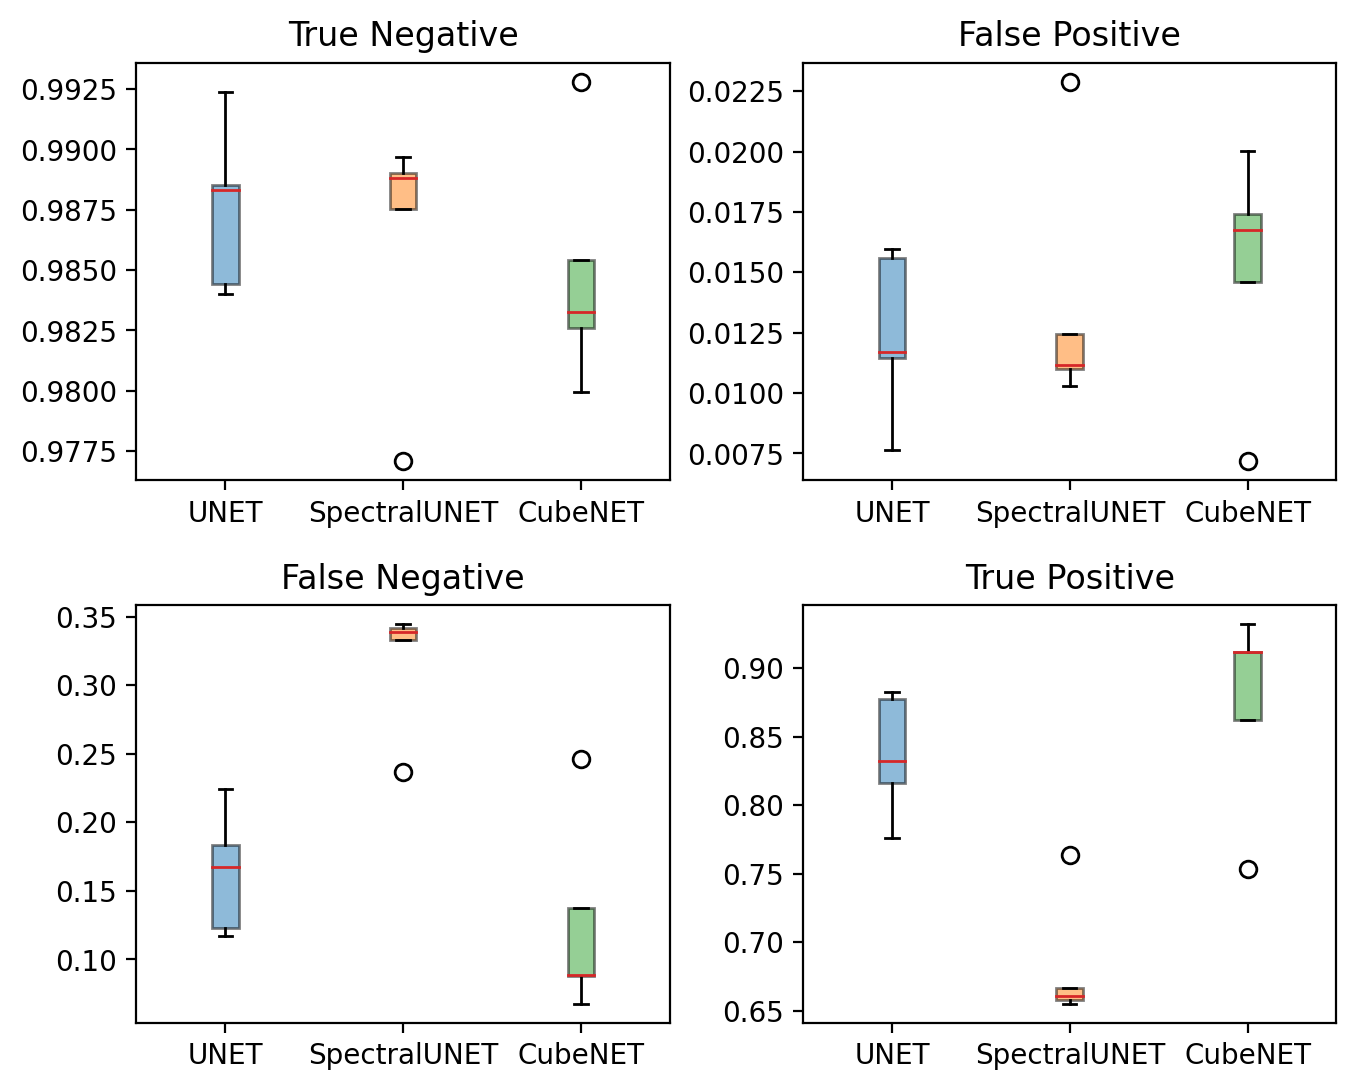

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=200)
fig.subplots_adjust(left=0.3, bottom=0.4, wspace=0.25, hspace=0.3)

plt_names = ["True Negative", "False Positive", "False Negative", "True Positive"]
colors = ['tab:blue', 'tab:orange', 'tab:green']
med_color = 'tab:red'
for idx, metric_str in enumerate(plt_names):
    r_idx = idx // 2
    c_idx = idx % 2
    axes[r_idx, c_idx].set_title(metric_str)
    # axes[r_idx, c_idx].set_xticks([0, 1, 2])
    axes[r_idx, c_idx].set_xticklabels(list(model_cmats.keys()))
    for mod_idx, model in enumerate(model_cmats):
        cmat = model_cmats[model]
        bplot = axes[r_idx, c_idx].boxplot(cmat[:, r_idx, c_idx], positions=[mod_idx], patch_artist=True)

        # fill with colors
        bplot['boxes'][0].set_facecolor(colors[mod_idx])
        bplot['boxes'][0].set_alpha(0.5)
        bplot['medians'][0].set_color(med_color)